--- SONUÇLAR ---
Tüm Özelliklerle Doğruluk (Baseline): 0.8553
300 Özellik ile Doğruluk (Optimized): 0.8421

Sınıflandırma Raporu (Optimize Edilmiş):

              precision    recall  f1-score   support

           0       0.78      0.54      0.64        39
           1       0.86      0.95      0.90       113

    accuracy                           0.84       152
   macro avg       0.82      0.74      0.77       152
weighted avg       0.84      0.84      0.83       152



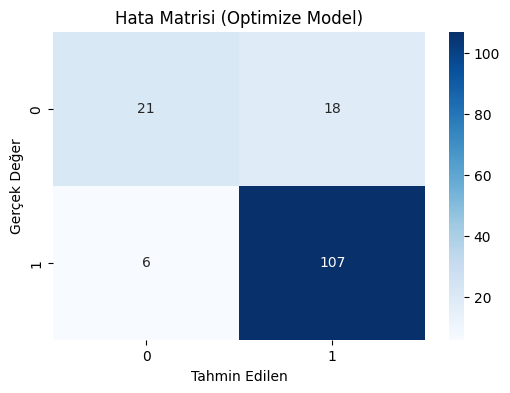

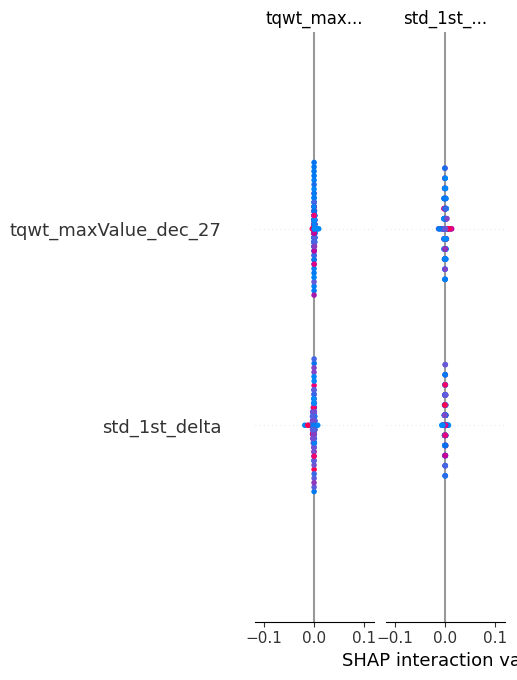

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. VERİ YÜKLEME VE SÜTUN DÜZENLEME
# Veri setindeki çift başlığı (multi-index) düzeltiyoruz
df = pd.read_csv('parkinson_data.csv', header=[0, 1])
df.columns = [col[1] if 'Unnamed' not in col[1] else col[0] for col in df.columns]

# Gereksiz ID sütununu atıyoruz ve hedef değişkeni (class) ayırıyoruz
X = df.drop(columns=['id', 'class'])
y = df['class']

# Eğitim ve test setine bölme (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. ÖNİŞLEME (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. BASELINE MODEL (Tüm Özelliklerle - Seçim Yapılmasaydı)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = rf_baseline.predict(X_test_scaled)
acc_baseline = accuracy_score(y_test, y_pred_baseline)

# 4. ÖZELLİK SEÇİMİ (Feature Selection)
importances = rf_baseline.feature_importances_
# En önemli 30 özelliğin indeksini buluyoruz
top_indices = np.argsort(importances)[-300:]
X_train_selected = X_train_scaled[:, top_indices]
X_test_selected = X_test_scaled[:, top_indices]

# 5. OPTİMİZE MODEL (Sadece seçilen 30 özellikle)
rf_optimized = RandomForestClassifier(n_estimators=100, random_state=42)
rf_optimized.fit(X_train_selected, y_train)
y_pred_optimized = rf_optimized.predict(X_test_selected)
acc_optimized = accuracy_score(y_test, y_pred_optimized)

# SONUÇLARIN KARŞILAŞTIRILMASI
print(f"--- SONUÇLAR ---")
print(f"Tüm Özelliklerle Doğruluk (Baseline): {acc_baseline:.4f}")
print(f"300 Özellik ile Doğruluk (Optimized): {acc_optimized:.4f}")
print("\nSınıflandırma Raporu (Optimize Edilmiş):\n")
print(classification_report(y_test, y_pred_optimized))

# 6. GÖRSELLEŞTİRME (Confusion Matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimized), annot=True, fmt='d', cmap='Blues')
plt.title('Hata Matrisi (Optimize Model)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

import shap
explainer = shap.TreeExplainer(rf_optimized)
shap_values = explainer.shap_values(X_test_selected)
shap.summary_plot(shap_values, X_test.iloc[:, top_indices])

Final Model Doğruluğu (Top 100): 0.8289

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.71      0.56      0.63        39
           1       0.86      0.92      0.89       113

    accuracy                           0.83       152
   macro avg       0.78      0.74      0.76       152
weighted avg       0.82      0.83      0.82       152



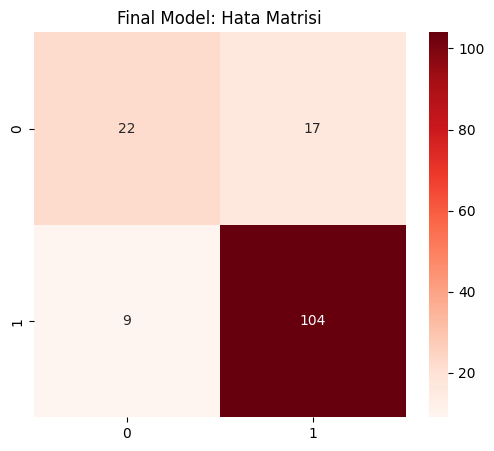

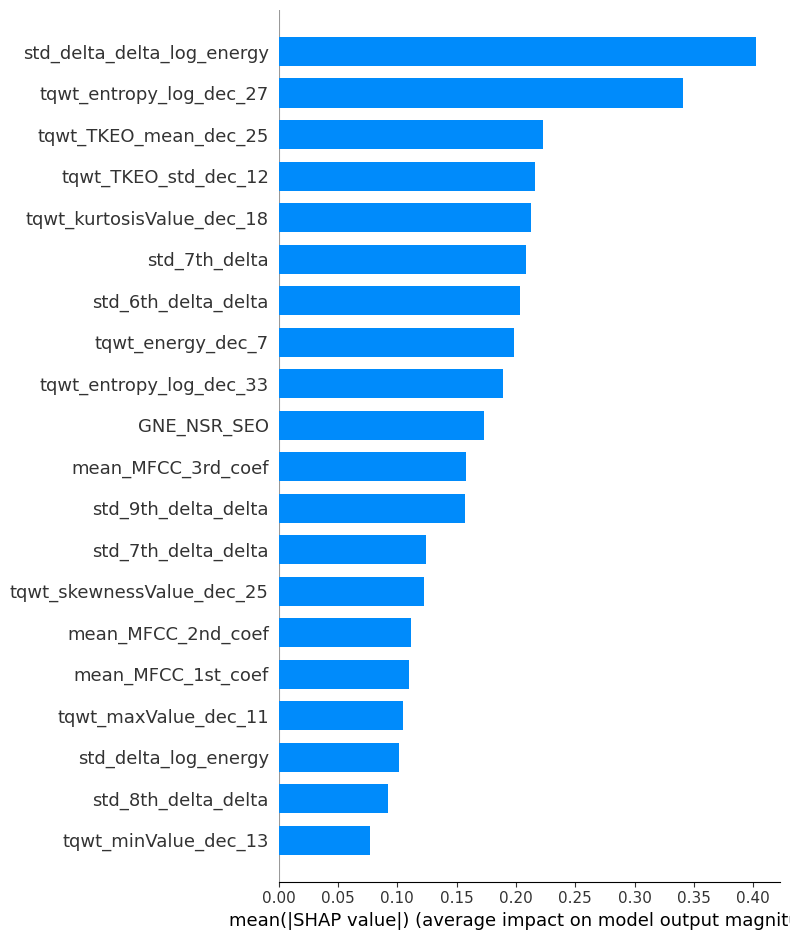

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. VERİ HAZIRLIĞI
df = pd.read_csv('parkinson_data.csv', header=[0, 1])
df.columns = [col[1] if 'Unnamed' not in col[1] else col[0] for col in df.columns]

# ID'yi atıyoruz, hedefi ayırıyoruz
X = df.drop(columns=['id', 'class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. ÖNİŞLEME
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. ÖZELLİK SEÇİMİ (Model Bazlı)
# Önce tüm özelliklerle en iyi modelimizi eğitiyoruz
gbm_full = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbm_full.fit(X_train_scaled, y_train)

# En önemli 100 özelliği seçiyoruz
importances = gbm_full.feature_importances_
top_indices = np.argsort(importances)[-100:]
X_train_sel = X_train_scaled[:, top_indices]
X_test_sel = X_test_scaled[:, top_indices]

# 4. FİNAL MODEL (Optimize Edilmiş)
gbm_final = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbm_final.fit(X_train_sel, y_train)
y_pred = gbm_final.predict(X_test_sel)

# 5. SONUÇLARIN RAPORLANMASI
print(f"Final Model Doğruluğu (Top 100): {accuracy_score(y_test, y_pred):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Confusion Matrix Görselleştirme
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Final Model: Hata Matrisi')
plt.show()

# 6. SHAP ANALİZİ (Görsel Oluşturma)
# Kendi bilgisayarında 'pip install shap' yüklü olmalıdır
import shap
explainer = shap.TreeExplainer(gbm_final)
shap_values = explainer.shap_values(X_test_sel)
shap.summary_plot(shap_values, X_test.iloc[:, top_indices], plot_type="bar")